# INF01090 - Ciência de Dados

# Lab Task 02 — Data Cleaning + Data Transformation (up to 4 people)

## Goal

Your team must turn a messy dataset into a **clean, consistent, and analysis-ready dataset**.

## Deliverables

By the end of the lab, your group should produce:

1. a cleaned dataset
2. a transformed dataset
3. a short written justification of your choices
4. a competition submission for **best analysis-ready dataset**

## Important

This lab is about:

- identifying data quality problems
- cleaning the data
- transforming variables
- documenting your decisions



## Suggested workflow

### Part A — Inspect
Look at the dataset carefully before changing anything.

### Part B — Clean
Fix duplicates, categories, dates, missing values, and invalid values.

### Part C — Transform
Create a small set of useful transformed variables.

### Part D — Compete
Submit the dataset your team believes is the **best prepared for future analysis**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
pd.set_option("display.max_columns", None)


## 1. Dataset

This synthetic dataset contains several realistic problems:

- duplicate rows
- inconsistent text categories
- mixed date formats
- missing values
- invalid ages
- numeric values stored as text
- one suspicious high-income value

Your task is to prepare the dataset for future analysis.


In [2]:
df_raw = pd.DataFrame({
    "customer_id": [101, 102, 103, 103, 104, 105, 106, 107, 108, 109, 110, 111],
    "name": ["Ana", " Bruno", "carla", "carla", "Daniel ", "Eva", None, "GUSTAVO", "Helena", "Igor", "Julia", "Julia"],
    "age": [25, 31, 200, 200, 29, np.nan, 41, -3, 36, 28, 28, 28],
    "city": ["Porto Alegre", "porto alegre", "São Paulo", "Sao Paulo", "Rio de Janeiro", "RIO DE JANEIRO", "Curitiba", "Curitiba ", None, "Porto Alegre", "São Paulo", "São Paulo"],
    "income": ["4200", "5100", "7900", "7900", "not informed", "6100", "5800", "4700", "250000", None, "4300", "4300"],
    "signup_date": ["2024-01-10", "2024/02/15", "15-03-2024", "15-03-2024", "2024-04-01", "2024-13-05", None, "2024-06-20", "2024-07-01", "2024-07-32", "2024-08-10", "2024-08-10"],
    "purchases": [3, 5, 7, 7, 2, 4, np.nan, 1, 30, 2, 3, 3],
    "gender": ["F", "M", "F", "F", "M", "F", "M", "m", "Female", "M", "F", "F"],
    "segment": ["Basic", "Basic", "Premium", "Premium", "Basic", "Premium", "Basic", "Basic", "Premium", "Basic", "Basic", "Basic"]
})

df_raw


,customer_id,name,age,city,income,signup_date,purchases,gender,segment
0,101,Ana,25.0,Porto Alegre,4200,2024-01-10,3.0,F,Basic
1,102,Bruno,31.0,porto alegre,5100,2024/02/15,5.0,M,Basic
2,103,carla,200.0,São Paulo,7900,15-03-2024,7.0,F,Premium
3,103,carla,200.0,Sao Paulo,7900,15-03-2024,7.0,F,Premium
4,104,Daniel,29.0,Rio de Janeiro,not informed,2024-04-01,2.0,M,Basic
5,105,Eva,NaN,RIO DE JANEIRO,6100,2024-13-05,4.0,F,Premium
6,106,NaN,41.0,Curitiba,5800,NaN,NaN,M,Basic
7,107,GUSTAVO,-3.0,Curitiba,4700,2024-06-20,1.0,m,Basic
8,108,Helena,36.0,NaN,250000,2024-07-01,30.0,Female,Premium
9,109,Igor,28.0,Porto Alegre,NaN,2024-07-32,2.0,M,Basic


## 2. Initial inspection

Inspect the dataset before changing it.


In [3]:
df_raw.shape


(12, 9)

In [4]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  12 non-null     int64  
 1   name         11 non-null     str    
 2   age          11 non-null     float64
 3   city         11 non-null     str    
 4   income       11 non-null     str    
 5   signup_date  11 non-null     str    
 6   purchases    11 non-null     float64
 7   gender       12 non-null     str    
 8   segment      12 non-null     str    
dtypes: float64(2), int64(1), str(6)
memory usage: 996.0 bytes


In [5]:
df_raw.isna().sum()


customer_id    0
name           1
age            1
city           1
income         1
signup_date    1
purchases      1
gender         0
segment        0
dtype: int64

In [6]:
df_raw.describe(include="all")


,customer_id,name,age,city,income,signup_date,purchases,gender,segment
count,12.000000,11,11.000000,11,11,11,11.000000,12,12
unique,NaN,9,NaN,8,9,9,NaN,4,2
top,NaN,carla,NaN,São Paulo,7900,15-03-2024,NaN,F,Basic
freq,NaN,2,NaN,3,2,2,NaN,6,8
mean,105.750000,NaN,58.454545,NaN,NaN,NaN,6.090909,NaN,NaN
std,3.278719,NaN,70.836945,NaN,NaN,NaN,8.166450,NaN,NaN
min,101.000000,NaN,-3.000000,NaN,NaN,NaN,1.000000,NaN,NaN
25%,103.000000,NaN,28.000000,NaN,NaN,NaN,2.500000,NaN,NaN
50%,105.500000,NaN,29.000000,NaN,NaN,NaN,3.000000,NaN,NaN
75%,108.250000,NaN,38.500000,NaN,NaN,NaN,6.000000,NaN,NaN


## 3. Create a working copy


In [7]:
df = df_raw.copy()


# Part A — Core Cleaning Tasks


## 4. Standardize text columns

Clean the following:

- `name`
- `city`
- `gender`

Suggestions:
- strip extra spaces
- normalize capitalization
- standardize labels


In [8]:
# TODO: clean names and cities
df["name"] = df["name"].str.strip().str.title()
df["city"] = df["city"].str.strip().str.title()
df["city"] = df["city"].replace({"Sao Paulo": "São Paulo", "Rio De Janeiro": "Rio de Janeiro"})
df

,customer_id,name,age,city,income,signup_date,purchases,gender,segment
0,101,Ana,25.0,Porto Alegre,4200,2024-01-10,3.0,F,Basic
1,102,Bruno,31.0,Porto Alegre,5100,2024/02/15,5.0,M,Basic
2,103,Carla,200.0,São Paulo,7900,15-03-2024,7.0,F,Premium
3,103,Carla,200.0,São Paulo,7900,15-03-2024,7.0,F,Premium
4,104,Daniel,29.0,Rio de Janeiro,not informed,2024-04-01,2.0,M,Basic
5,105,Eva,NaN,Rio de Janeiro,6100,2024-13-05,4.0,F,Premium
6,106,NaN,41.0,Curitiba,5800,NaN,NaN,M,Basic
7,107,Gustavo,-3.0,Curitiba,4700,2024-06-20,1.0,m,Basic
8,108,Helena,36.0,NaN,250000,2024-07-01,30.0,Female,Premium
9,109,Igor,28.0,Porto Alegre,NaN,2024-07-32,2.0,M,Basic


In [9]:
# TODO: standardize gender values
df["gender"] = df["gender"].str.strip().str.upper()
df["gender"] = df["gender"].replace({"MALE": "M", "FEMALE": "F"})
df

,customer_id,name,age,city,income,signup_date,purchases,gender,segment
0,101,Ana,25.0,Porto Alegre,4200,2024-01-10,3.0,F,Basic
1,102,Bruno,31.0,Porto Alegre,5100,2024/02/15,5.0,M,Basic
2,103,Carla,200.0,São Paulo,7900,15-03-2024,7.0,F,Premium
3,103,Carla,200.0,São Paulo,7900,15-03-2024,7.0,F,Premium
4,104,Daniel,29.0,Rio de Janeiro,not informed,2024-04-01,2.0,M,Basic
5,105,Eva,NaN,Rio de Janeiro,6100,2024-13-05,4.0,F,Premium
6,106,NaN,41.0,Curitiba,5800,NaN,NaN,M,Basic
7,107,Gustavo,-3.0,Curitiba,4700,2024-06-20,1.0,M,Basic
8,108,Helena,36.0,NaN,250000,2024-07-01,30.0,F,Premium
9,109,Igor,28.0,Porto Alegre,NaN,2024-07-32,2.0,M,Basic


In [10]:
# TODO: inspect unique values after standardization
df["gender"].unique()
df["city"].unique()
df["name"].unique()

<StringArray>
[    'Ana',   'Bruno',   'Carla',  'Daniel',     'Eva',       nan, 'Gustavo',
  'Helena',    'Igor',   'Julia']
Length: 10, dtype: str

## 5. Parse dates with mixed formats

The dataset contains valid dates written in multiple formats:

- `YYYY-MM-DD`
- `YYYY/MM/DD`
- `DD-MM-YYYY`

You should preserve valid information and normalize it into a unified format.


In [11]:
# TODO: complete this helper and apply it to signup_date

def parse_mixed_date(x):
    if pd.isna(x):
        return pd.NaT

    x = str(x).strip()
    if x == "":
        return pd.NaT

    formats = [
        "%Y-%m-%d",
        "%Y/%m/%d",
        "%d-%m-%Y",
    ]

    for fmt in formats:
        try:
            return pd.to_datetime(x, format=fmt)
        except ValueError:
            continue

    return pd.to_datetime(x, errors="coerce")

# Your code here
df["signup_date"] = df["signup_date"].apply(parse_mixed_date)
df

,customer_id,name,age,city,income,signup_date,purchases,gender,segment
0,101,Ana,25.0,Porto Alegre,4200,2024-01-10,3.0,F,Basic
1,102,Bruno,31.0,Porto Alegre,5100,2024-02-15,5.0,M,Basic
2,103,Carla,200.0,São Paulo,7900,2024-03-15,7.0,F,Premium
3,103,Carla,200.0,São Paulo,7900,2024-03-15,7.0,F,Premium
4,104,Daniel,29.0,Rio de Janeiro,not informed,2024-04-01,2.0,M,Basic
5,105,Eva,NaN,Rio de Janeiro,6100,NaT,4.0,F,Premium
6,106,NaN,41.0,Curitiba,5800,NaT,NaN,M,Basic
7,107,Gustavo,-3.0,Curitiba,4700,2024-06-20,1.0,M,Basic
8,108,Helena,36.0,NaN,250000,2024-07-01,30.0,F,Premium
9,109,Igor,28.0,Porto Alegre,NaN,NaT,2.0,M,Basic


## 6. Remove exact duplicates

Inspect duplicate rows and then remove them.


In [12]:
# TODO: count duplicated rows
df.duplicated().sum()

np.int64(1)

In [13]:
# TODO: display duplicated rows
df[df.duplicated(keep=False)].sort_values("customer_id")

,customer_id,name,age,city,income,signup_date,purchases,gender,segment
2,103,Carla,200.0,São Paulo,7900,2024-03-15,7.0,F,Premium
3,103,Carla,200.0,São Paulo,7900,2024-03-15,7.0,F,Premium


In [14]:
# TODO: remove exact duplicates
df = df.drop_duplicates()
df

,customer_id,name,age,city,income,signup_date,purchases,gender,segment
0,101,Ana,25.0,Porto Alegre,4200,2024-01-10,3.0,F,Basic
1,102,Bruno,31.0,Porto Alegre,5100,2024-02-15,5.0,M,Basic
2,103,Carla,200.0,São Paulo,7900,2024-03-15,7.0,F,Premium
4,104,Daniel,29.0,Rio de Janeiro,not informed,2024-04-01,2.0,M,Basic
5,105,Eva,NaN,Rio de Janeiro,6100,NaT,4.0,F,Premium
6,106,NaN,41.0,Curitiba,5800,NaT,NaN,M,Basic
7,107,Gustavo,-3.0,Curitiba,4700,2024-06-20,1.0,M,Basic
8,108,Helena,36.0,NaN,250000,2024-07-01,30.0,F,Premium
9,109,Igor,28.0,Porto Alegre,NaN,NaT,2.0,M,Basic
10,110,Julia,28.0,São Paulo,4300,2024-08-10,3.0,F,Basic


## 7. Convert numeric text and fix invalid ages

Tasks:
- convert `income` to numeric
- identify impossible ages
- replace impossible ages with missing values


In [15]:
# TODO: convert income to numeric
df["income"] = pd.to_numeric(df["income"].replace("not informed", np.nan), errors="coerce")
df

,customer_id,name,age,city,income,signup_date,purchases,gender,segment
0,101,Ana,25.0,Porto Alegre,4200.0,2024-01-10,3.0,F,Basic
1,102,Bruno,31.0,Porto Alegre,5100.0,2024-02-15,5.0,M,Basic
2,103,Carla,200.0,São Paulo,7900.0,2024-03-15,7.0,F,Premium
4,104,Daniel,29.0,Rio de Janeiro,NaN,2024-04-01,2.0,M,Basic
5,105,Eva,NaN,Rio de Janeiro,6100.0,NaT,4.0,F,Premium
6,106,NaN,41.0,Curitiba,5800.0,NaT,NaN,M,Basic
7,107,Gustavo,-3.0,Curitiba,4700.0,2024-06-20,1.0,M,Basic
8,108,Helena,36.0,NaN,250000.0,2024-07-01,30.0,F,Premium
9,109,Igor,28.0,Porto Alegre,NaN,NaT,2.0,M,Basic
10,110,Julia,28.0,São Paulo,4300.0,2024-08-10,3.0,F,Basic


In [16]:
# TODO: identify invalid ages
df[(df["age"] < 0) | (df["age"] > 120)]

,customer_id,name,age,city,income,signup_date,purchases,gender,segment
2,103,Carla,200.0,São Paulo,7900.0,2024-03-15,7.0,F,Premium
7,107,Gustavo,-3.0,Curitiba,4700.0,2024-06-20,1.0,M,Basic


In [17]:
# TODO: replace invalid ages with NaN
df.loc[(df["age"] < 0) | (df["age"] > 120), "age"] = np.nan
df

,customer_id,name,age,city,income,signup_date,purchases,gender,segment
0,101,Ana,25.0,Porto Alegre,4200.0,2024-01-10,3.0,F,Basic
1,102,Bruno,31.0,Porto Alegre,5100.0,2024-02-15,5.0,M,Basic
2,103,Carla,NaN,São Paulo,7900.0,2024-03-15,7.0,F,Premium
4,104,Daniel,29.0,Rio de Janeiro,NaN,2024-04-01,2.0,M,Basic
5,105,Eva,NaN,Rio de Janeiro,6100.0,NaT,4.0,F,Premium
6,106,NaN,41.0,Curitiba,5800.0,NaT,NaN,M,Basic
7,107,Gustavo,NaN,Curitiba,4700.0,2024-06-20,1.0,M,Basic
8,108,Helena,36.0,NaN,250000.0,2024-07-01,30.0,F,Premium
9,109,Igor,28.0,Porto Alegre,NaN,NaT,2.0,M,Basic
10,110,Julia,28.0,São Paulo,4300.0,2024-08-10,3.0,F,Basic


## 8. Handle missing values

For this lab, use a simple strategy unless your group has a justified alternative.

Suggestion:
- median for numerical variables
- `"Unknown"` for selected categorical variables


In [18]:
# TODO: inspect missing values
df.isna().sum()

customer_id    0
name           1
age            3
city           1
income         2
signup_date    3
purchases      1
gender         0
segment        0
dtype: int64

In [20]:
# TODO: fill missing values
df["age"] = df["age"].fillna(df["age"].median()) #arredondar para inteiro mais próximo?
df["income"] = df["income"].fillna(df["income"].median())
df["purchases"] = df["purchases"].fillna(df["purchases"].median())
df["signup_date"] = df["signup_date"].fillna(df["signup_date"].median())
df["name"] = df["name"].fillna("Unknown")
df["city"] = df["city"].fillna("Unknown")
df

,customer_id,name,age,city,income,signup_date,purchases,gender,segment
0,101,Ana,25.0,Porto Alegre,4200.0,2024-01-10,3.0,F,Basic
1,102,Bruno,31.0,Porto Alegre,5100.0,2024-02-15,5.0,M,Basic
2,103,Carla,28.5,São Paulo,7900.0,2024-03-15,7.0,F,Premium
4,104,Daniel,29.0,Rio de Janeiro,5100.0,2024-04-01,2.0,M,Basic
5,105,Eva,28.5,Rio de Janeiro,6100.0,2024-05-11,4.0,F,Premium
6,106,Unknown,41.0,Curitiba,5800.0,2024-05-11,3.0,M,Basic
7,107,Gustavo,28.5,Curitiba,4700.0,2024-06-20,1.0,M,Basic
8,108,Helena,36.0,Unknown,250000.0,2024-07-01,30.0,F,Premium
9,109,Igor,28.0,Porto Alegre,5100.0,2024-05-11,2.0,M,Basic
10,110,Julia,28.0,São Paulo,4300.0,2024-08-10,3.0,F,Basic


## 9. Inspect the suspicious income outlier

There is one very large income value.

Tasks:
- make a boxplot
- inspect the suspicious row
- decide whether to keep, cap, or otherwise treat it
- justify your choice later


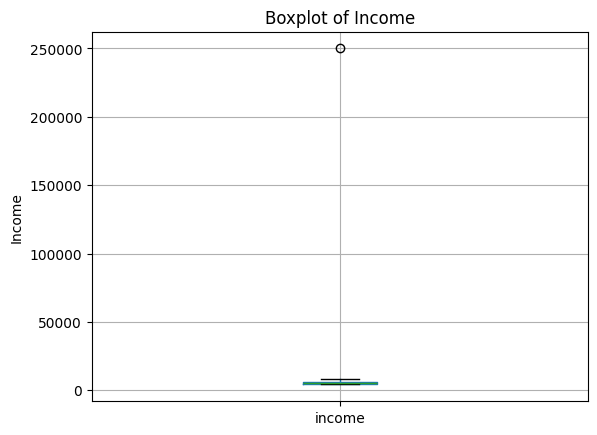

In [ ]:
# TODO: create a boxplot for income_num
df.boxplot(column="income")
plt.title("Boxplot of Income")
plt.ylabel("Income")
plt.show()
#deixar o outlier?

# Part B — Core Transformation Tasks


## 10. Create transformed variables

Create the following:

- `signup_month`
- `income_minmax`
- `income_log`
- `segment_encoded`
- `purchases_per_age`
- `income_per_purchase`


In [ ]:
# TODO: create the transformed columns listed above
df["signup_month"] = df["signup_date"].dt.month
df["income_minmax"] = df["income"] / df["income"].max() #tá certo isso?
df["income_log"] = np.log(df["income"]) #tá certo isso?
df["segment_encoded"] = df["segment"].map({"Basic": 0, "Premium": 1})
df["purchases_per_age"] = df["purchases"] / df["age"]
df["income_per_purchase"] = df["income"] / df["purchases"]
df

,customer_id,name,age,city,income,signup_date,purchases,gender,segment,signup_month,income_minmax,income_log,segment_encoded,purchases_per_age,income_per_purchase
0,101,Ana,25.0,Porto Alegre,4200.0,2024-01-10,3.0,F,Basic,1,0.0168,8.342840,0,0.120000,1400.000000
1,102,Bruno,31.0,Porto Alegre,5100.0,2024-02-15,5.0,M,Basic,2,0.0204,8.536996,0,0.161290,1020.000000
2,103,Carla,28.5,São Paulo,7900.0,2024-03-15,7.0,F,Premium,3,0.0316,8.974618,1,0.245614,1128.571429
4,104,Daniel,29.0,Rio de Janeiro,5100.0,2024-04-01,2.0,M,Basic,4,0.0204,8.536996,0,0.068966,2550.000000
5,105,Eva,28.5,Rio de Janeiro,6100.0,2024-05-11,4.0,F,Premium,5,0.0244,8.716044,1,0.140351,1525.000000
6,106,Unknown,41.0,Curitiba,5800.0,2024-05-11,3.0,M,Basic,5,0.0232,8.665613,0,0.073171,1933.333333
7,107,Gustavo,28.5,Curitiba,4700.0,2024-06-20,1.0,M,Basic,6,0.0188,8.455318,0,0.035088,4700.000000
8,108,Helena,36.0,Unknown,250000.0,2024-07-01,30.0,F,Premium,7,1.0000,12.429216,1,0.833333,8333.333333
9,109,Igor,28.0,Porto Alegre,5100.0,2024-05-11,2.0,M,Basic,5,0.0204,8.536996,0,0.071429,2550.000000
10,110,Julia,28.0,São Paulo,4300.0,2024-08-10,3.0,F,Basic,8,0.0172,8.366370,0,0.107143,1433.333333


## 11. One-hot encode one categorical variable

Use one-hot encoding for the `city` column.


In [23]:
# TODO: create city dummy variables
df = pd.get_dummies(df, columns=["city"], prefix="city")
df

,customer_id,name,age,income,signup_date,purchases,gender,segment,signup_month,income_minmax,income_log,segment_encoded,purchases_per_age,income_per_purchase,city_Curitiba,city_Porto Alegre,city_Rio de Janeiro,city_São Paulo,city_Unknown
0,101,Ana,25.0,4200.0,2024-01-10,3.0,F,Basic,1,0.0168,8.342840,0,0.120000,1400.000000,False,True,False,False,False
1,102,Bruno,31.0,5100.0,2024-02-15,5.0,M,Basic,2,0.0204,8.536996,0,0.161290,1020.000000,False,True,False,False,False
2,103,Carla,28.5,7900.0,2024-03-15,7.0,F,Premium,3,0.0316,8.974618,1,0.245614,1128.571429,False,False,False,True,False
4,104,Daniel,29.0,5100.0,2024-04-01,2.0,M,Basic,4,0.0204,8.536996,0,0.068966,2550.000000,False,False,True,False,False
5,105,Eva,28.5,6100.0,2024-05-11,4.0,F,Premium,5,0.0244,8.716044,1,0.140351,1525.000000,False,False,True,False,False
6,106,Unknown,41.0,5800.0,2024-05-11,3.0,M,Basic,5,0.0232,8.665613,0,0.073171,1933.333333,True,False,False,False,False
7,107,Gustavo,28.5,4700.0,2024-06-20,1.0,M,Basic,6,0.0188,8.455318,0,0.035088,4700.000000,True,False,False,False,False
8,108,Helena,36.0,250000.0,2024-07-01,30.0,F,Premium,7,1.0000,12.429216,1,0.833333,8333.333333,False,False,False,False,True
9,109,Igor,28.0,5100.0,2024-05-11,2.0,M,Basic,5,0.0204,8.536996,0,0.071429,2550.000000,False,True,False,False,False
10,110,Julia,28.0,4300.0,2024-08-10,3.0,F,Basic,8,0.0172,8.366370,0,0.107143,1433.333333,False,False,False,True,False


## 12. Build the final transformed dataset

Create a compact final table ready for future analysis.
Include:
- cleaned core columns
- transformed columns
- one-hot encoded city columns


In [ ]:
# TODO: build df_final
#O que falta: ver os comentários anteriores com dúvidas e decidir o que fazer com eles
#Fazer o 12 e o 13
#Revisar todos os demais para verificar se estão corretos e se é necessário fazer algo mais
#Escrever na parte "Team Explanation"

## 13. Optional summary table

Create a small grouped summary by city with:
- average income
- total purchases


In [18]:
# TODO: grouped summary by city


# Part C — Competition


## 14. Competition: Best Analysis-Ready Dataset

Your group will submit:

1. one final cleaned + transformed dataset
2. one short markdown explanation
3. one short “quality report”

### Judging criteria
- correctness
- consistency
- clarity
- usefulness for future analysis
- quality of justification

### Tip
A dataset is not “better” just because it has more columns.
It is better if it is **clean, meaningful, and well documented**.


## 15. Team explanation

In the markdown cell below, explain:

- which duplicate handling you used
- how you standardized categories
- how you parsed dates
- how you handled missing values
- what you did with the suspicious income value
- why your final transformed dataset is a good submission


**Write your team explanation here.**


## 16. Quick checklist before submission

Make sure your group has:

- removed exact duplicates
- standardized text categories
- parsed dates into one format
- converted income to numeric
- handled invalid ages
- handled missing values
- created the required transformed columns
- created one-hot encoded city columns
- built a final dataset
- written a short justification


# Final takeaway

A dataset becomes useful through a sequence of careful decisions.

In this lab, the main goal is not to “finish fast,” but to produce a dataset that is:

- correct
- consistent
- clearly documented
- ready for future analysis
